In [26]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Configure paths
OUTPUT_DIR = Path(__file__).parents[2] / 'Python' / 'output' if '__file__' in globals() else Path('..') / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path(__file__).parents[2] / 'input' if '__file__' in globals() else Path('..') / '..' / 'input'

# Set random seed for reproducibility
np.random.seed(123)

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully")
print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Data directory: {DATA_DIR}")
print(f"✓ Random seed set to: 123")

✓ Libraries imported successfully
✓ Output directory: ../output
✓ Data directory: ../../input
✓ Random seed set to: 123


# Question 2 - Double/Debiased Machine Learning (12 points)

This notebook implements Double/Debiased Machine Learning (DML) to estimate causal effects using the `penn_jae.csv` dataset.

## Overview

### **Part I: Data Cleaning and Setup (1.5 points)**
- Load and filter the Pennsylvania Reemployment dataset
- Create treatment variable (T4), outcome (log duration), and feature matrix
- Prepare data for causal inference

### **Part II: Debiased ML with Cross-Fitting (6 points)**
- Implement DML function with cross-fitting for the Partially Linear Model
- Estimate treatment effects using OLS, Lasso, Random Forest, and Neural Networks
- Present comprehensive results and select best model(s)

### **Part III: DML without Cross-Fitting (4.5 points)**
- Implement DML without cross-fitting (potential overfitting)
- Compare RMSE and bias between cross-fitting and no cross-fitting
- Analyze why cross-fitting is essential for valid causal inference

---

## Research Question

**What is the causal effect of extended unemployment benefits (treatment group 4) on the log duration of unemployment?**

---

# PART I: Data Cleaning and Setup (1.5 points)

## 1.1 Load Dataset (0.5 points)

Loading the Pennsylvania Reemployment Bonus Experiment dataset from `penn_jae.csv`.

In [27]:
# Load the dataset
data_path = DATA_DIR / 'penn_jae.csv'
df_raw = pd.read_csv(data_path)

print(f"✓ Dataset loaded successfully")
print(f"  Original shape: {df_raw.shape}")
print(f"  Columns: {list(df_raw.columns)}")
print(f"\n✓ First few rows:")
df_raw.head()

✓ Dataset loaded successfully
  Original shape: (13913, 24)
  Columns: ['Unnamed: 0', 'abdt', 'tg', 'inuidur1', 'inuidur2', 'female', 'black', 'hispanic', 'othrace', 'dep', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'recall', 'agelt35', 'agegt54', 'durable', 'nondurable', 'lusd', 'husd', 'muld']

✓ First few rows:


,Unnamed: 0,abdt,tg,inuidur1,inuidur2,female,black,hispanic,othrace,dep,...,q5,q6,recall,agelt35,agegt54,durable,nondurable,lusd,husd,muld
0,1,10824,0,18,18,0,0,0,0,2,...,1,0,0,0,0,0,0,0,1,0
1,2,10635,2,7,3,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
2,3,10551,5,18,6,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
3,4,10824,0,1,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,5,10747,0,27,27,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [28]:
# Explore treatment groups
print("Treatment Group (tg) distribution:")
print(df_raw['tg'].value_counts().sort_index())
print(f"\n✓ We will keep only tg = 0 (control) and tg = 4 (treatment)")

Treatment Group (tg) distribution:
tg
0    3354
1    1385
2    2428
3    1885
4    1745
5    1831
6    1285
Name: count, dtype: int64

✓ We will keep only tg = 0 (control) and tg = 4 (treatment)


---

## 1.2 Data Cleaning and Feature Engineering (1 point)

**Steps:**
1. Filter observations where `tg` ∈ {0, 4}
2. Create treatment indicator `T4` = 1 if tg = 4, else 0
3. Create outcome variable `y` = log(`inuidur1`)
4. Create dummy variables for `dep` categories
5. Select and prepare feature matrix `X`

In [29]:
# Step 1: Filter to keep only tg = 0 and tg = 4
df = df_raw[df_raw['tg'].isin([0, 4])].copy()
print(f"✓ Step 1: Filtered to tg ∈ {{0, 4}}")
print(f"  Shape after filtering: {df.shape}")

# Step 2: Create treatment variable T4
df['T4'] = (df['tg'] == 4).astype(int)
print(f"\n✓ Step 2: Created treatment variable T4")
print(f"  T4=0 (control): {(df['T4']==0).sum()} observations")
print(f"  T4=1 (treatment): {(df['T4']==1).sum()} observations")

# Step 3: Create outcome variable y = log(inuidur1)
# Handle zeros by replacing with NaN first, then filling
df['y'] = np.log(df['inuidur1'].replace(0, np.nan))
print(f"\n✓ Step 3: Created outcome y = log(inuidur1)")
print(f"  Mean: {df['y'].mean():.4f}")
print(f"  Std: {df['y'].std():.4f}")
print(f"  Missing values: {df['y'].isna().sum()}")

# Step 4: Create dummy variables for dep
print(f"\n✓ Step 4: Creating dummy variables for 'dep'")
print(f"  Original 'dep' categories: {sorted(df['dep'].unique())}")
for c in [0, 1, 2]:
    df[f'dep_{c}'] = (df['dep'] == c).astype(int)
print(f"  Created: dep_0, dep_1, dep_2")

# Step 5: Define feature set X
x_cols = [
    'female', 'black', 'othrace',           # Demographics
    'dep_1', 'dep_2',                       # Dependents (excluding dep_0 as baseline)
    'q2', 'q3', 'q4', 'q5', 'q6',          # Quarter dummies
    'recall', 'agelt35', 'agegt54',         # Age and recall status
    'durable', 'nondurable', 'lusd', 'husd' # Industry indicators
]

print(f"\n✓ Step 5: Defined feature matrix X with {len(x_cols)} features:")
print(f"  {x_cols}")

# Select final dataset and drop missing values
df_clean = df[x_cols + ['y', 'T4']].copy()
print(f"\nBefore dropping NAs: {df_clean.shape}")
df_clean = df_clean.dropna()
print(f"After dropping NAs: {df_clean.shape}")

# Extract arrays for modeling
X = df_clean[x_cols].astype(float)
y = df_clean['y'].values
d = df_clean['T4'].values

print(f"\n{'='*60}")
print(f"FINAL DATA SUMMARY")
print(f"{'='*60}")
print(f"Features (X): {X.shape}")
print(f"Outcome (y): {y.shape}, mean = {y.mean():.4f}")
print(f"Treatment (d): {d.shape}, treated = {d.sum()} ({100*d.mean():.1f}%)")
print(f"{'='*60}")

✓ Step 1: Filtered to tg ∈ {0, 4}
  Shape after filtering: (5099, 24)

✓ Step 2: Created treatment variable T4
  T4=0 (control): 3354 observations
  T4=1 (treatment): 1745 observations

✓ Step 3: Created outcome y = log(inuidur1)
  Mean: 2.0276
  Std: 1.2148
  Missing values: 0

✓ Step 4: Creating dummy variables for 'dep'
  Original 'dep' categories: [np.int64(0), np.int64(1), np.int64(2)]
  Created: dep_0, dep_1, dep_2

✓ Step 5: Defined feature matrix X with 17 features:
  ['female', 'black', 'othrace', 'dep_1', 'dep_2', 'q2', 'q3', 'q4', 'q5', 'q6', 'recall', 'agelt35', 'agegt54', 'durable', 'nondurable', 'lusd', 'husd']

Before dropping NAs: (5099, 19)
After dropping NAs: (5099, 19)

FINAL DATA SUMMARY
Features (X): (5099, 17)
Outcome (y): (5099,), mean = 2.0276
Treatment (d): (5099,), treated = 1745 (34.2%)


---

# PART II: Debiased ML with Cross-Fitting (6 points)

## 2.1 DML Function Implementation (1 point)

Implementing the **Double/Debiased Machine Learning** estimator for the **Partially Linear Model** with **cross-fitting**.

### The Partially Linear Model:

$$y = d\theta_0 + g_0(x) + \epsilon$$
$$d = m_0(x) + \nu$$

where:
- $\theta_0$ is the causal parameter of interest (ATE)
- $g_0(x) = E[y|x]$ is the conditional expectation of outcome
- $m_0(x) = E[d|x]$ is the conditional expectation of treatment (propensity)

### DML Estimation Procedure:

1. **Split** data into K folds
2. **For each fold k:**
   - Train ML models for $\hat{g}$ and $\hat{m}$ on data excluding fold k
   - Predict on fold k: $\hat{y}_i = \hat{g}(x_i)$ and $\hat{d}_i = \hat{m}(x_i)$
3. **Residualize**: $\tilde{y} = y - \hat{y}$ and $\tilde{d} = d - \hat{d}$
4. **Estimate**: $\hat{\theta} = (\tilde{d}'\tilde{d})^{-1}\tilde{d}'\tilde{y}$
5. **Compute SE**: Based on residual variance

In [30]:
def dml_plm(X, y, d, ml_y, ml_d, n_splits=2, random_state=123):
    """
    Double/Debiased Machine Learning for Partially Linear Model with Cross-Fitting
    
    Parameters:
    -----------
    X : pd.DataFrame or np.array
        Feature matrix (n x p)
    y : np.array
        Outcome variable (n,)
    d : np.array
        Treatment variable (n,)
    ml_y : sklearn estimator
        Machine learning model for E[y|X]
    ml_d : sklearn estimator
        Machine learning model for E[d|X]
    n_splits : int
        Number of folds for cross-fitting (default=2)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    theta : float
        Estimated treatment effect
    se : float
        Standard error of theta
    y_tilde : np.array
        Residualized outcome
    d_tilde : np.array
        Residualized treatment
    rmse_y : float
        RMSE for outcome prediction
    rmse_d : float
        RMSE for treatment prediction
    """
    # Initialize arrays for out-of-sample predictions
    y_pred = np.zeros_like(y, dtype=float)
    d_pred = np.zeros_like(d, dtype=float)
    
    # K-fold cross-fitting
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    for train_idx, test_idx in kf.split(X):
        # Split data
        if isinstance(X, pd.DataFrame):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        else:
            X_train, X_test = X[train_idx], X[test_idx]
        
        y_train, y_test = y[train_idx], y[test_idx]
        d_train, d_test = d[train_idx], d[test_idx]
        
        # Fit models on training fold
        ml_y_clone = clone(ml_y)
        ml_d_clone = clone(ml_d)
        
        ml_y_clone.fit(X_train, y_train)
        ml_d_clone.fit(X_train, d_train)
        
        # Predict on test fold (out-of-sample)
        y_pred[test_idx] = ml_y_clone.predict(X_test)
        d_pred[test_idx] = ml_d_clone.predict(X_test)
    
    # Compute residuals
    y_tilde = y - y_pred
    d_tilde = d - d_pred
    
    # Estimate theta via OLS of y_tilde on d_tilde
    theta = np.linalg.lstsq(d_tilde.reshape(-1, 1), y_tilde, rcond=None)[0][0]
    
    # Compute standard error
    residuals = y_tilde - theta * d_tilde
    sigma2 = np.mean(residuals**2)
    var_theta = sigma2 / np.mean(d_tilde**2) / len(y)
    se = np.sqrt(var_theta)
    
    # Compute RMSE for predictions
    rmse_y = np.sqrt(mean_squared_error(y, y_pred))
    rmse_d = np.sqrt(mean_squared_error(d, d_pred))
    
    return theta, se, y_tilde, d_tilde, rmse_y, rmse_d

print("✓ DML function with cross-fitting implemented successfully")

✓ DML function with cross-fitting implemented successfully


---

## 2.2 Model Training: OLS, Lasso, Random Forest (2 points)

Training DML with multiple machine learning algorithms:

In [31]:
# Define models for both y and d
models_y = {
    'OLS': LinearRegression(),
    'Lasso': LassoCV(cv=5, random_state=123),
    'RF': RandomForestRegressor(n_estimators=500, max_depth=10, random_state=123, n_jobs=-1)
}

models_d = {
    'OLS': LinearRegression(),
    'Lasso': LassoCV(cv=5, random_state=123),
    'RF': RandomForestRegressor(n_estimators=500, max_depth=10, random_state=123, n_jobs=-1)
}

# Store results
results_dml_cf = []

print("="*80)
print("TRAINING DML MODELS WITH CROSS-FITTING")
print("="*80)

# Train all combinations
for name_y in models_y.keys():
    for name_d in models_d.keys():
        print(f"\n Training: y ~ {name_y}, d ~ {name_d}")
        
        ml_y = clone(models_y[name_y])
        ml_d = clone(models_d[name_d])
        
        theta, se, y_tilde, d_tilde, rmse_y, rmse_d = dml_plm(
            X, y, d, ml_y=ml_y, ml_d=ml_d, n_splits=2, random_state=123
        )
        
        # Compute confidence interval and t-statistic
        ci_lower = theta - 1.96 * se
        ci_upper = theta + 1.96 * se
        t_stat = theta / se
        p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
        
        results_dml_cf.append({
            'Model_y': name_y,
            'Model_d': name_d,
            'Theta': theta,
            'SE': se,
            'CI_Lower': ci_lower,
            'CI_Upper': ci_upper,
            't_stat': t_stat,
            'p_value': p_value,
            'RMSE_y': rmse_y,
            'RMSE_d': rmse_d
        })
        
        print(f"   θ = {theta:.4f} (SE = {se:.4f})")
        print(f"   95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        print(f"   RMSE: y={rmse_y:.4f}, d={rmse_d:.4f}")

print("\n" + "="*80)
print("✓ All OLS, Lasso, and RF models trained successfully")
print("="*80)

TRAINING DML MODELS WITH CROSS-FITTING

 Training: y ~ OLS, d ~ OLS
   θ = -0.0799 (SE = 0.0351)
   95% CI: [-0.1488, -0.0110]
   RMSE: y=1.1964, d=0.4766

 Training: y ~ OLS, d ~ Lasso
   θ = -0.0751 (SE = 0.0353)
   95% CI: [-0.1443, -0.0060]
   RMSE: y=1.1964, d=0.4746

 Training: y ~ OLS, d ~ RF
   θ = -0.0729 (SE = 0.0344)
   95% CI: [-0.1404, -0.0054]
   RMSE: y=1.1964, d=0.4863

 Training: y ~ Lasso, d ~ OLS
   θ = -0.0813 (SE = 0.0351)
   95% CI: [-0.1502, -0.0125]
   RMSE: y=1.1963, d=0.4766

 Training: y ~ Lasso, d ~ Lasso
   θ = -0.0768 (SE = 0.0353)
   95% CI: [-0.1460, -0.0077]
   RMSE: y=1.1963, d=0.4746

 Training: y ~ Lasso, d ~ RF
   θ = -0.0729 (SE = 0.0344)
   95% CI: [-0.1404, -0.0054]
   RMSE: y=1.1964, d=0.4863

 Training: y ~ Lasso, d ~ OLS
   θ = -0.0813 (SE = 0.0351)
   95% CI: [-0.1502, -0.0125]
   RMSE: y=1.1963, d=0.4766

 Training: y ~ Lasso, d ~ Lasso
   θ = -0.0768 (SE = 0.0353)
   95% CI: [-0.1460, -0.0077]
   RMSE: y=1.1963, d=0.4746

 Training: y ~ Las

---

## 2.3 Neural Network Model (2 points)

Training DML with Neural Network architectures:

In [32]:
# Define Neural Network models
models_nn = {
    'NN_Small': MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=123, early_stopping=True),
    'NN_Medium': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=123, early_stopping=True),
    'NN_Large': MLPRegressor(hidden_layer_sizes=(100, 100, 50), max_iter=1000, random_state=123, early_stopping=True)
}

print("="*80)
print("TRAINING NEURAL NETWORK MODELS")
print("="*80)

for name_nn in models_nn.keys():
    print(f"\n Training: y ~ {name_nn}, d ~ {name_nn}")
    
    ml_y = clone(models_nn[name_nn])
    ml_d = clone(models_nn[name_nn])
    
    theta, se, y_tilde, d_tilde, rmse_y, rmse_d = dml_plm(
        X, y, d, ml_y=ml_y, ml_d=ml_d, n_splits=2, random_state=123
    )
    
    # Compute statistics
    ci_lower = theta - 1.96 * se
    ci_upper = theta + 1.96 * se
    t_stat = theta / se
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    results_dml_cf.append({
        'Model_y': name_nn,
        'Model_d': name_nn,
        'Theta': theta,
        'SE': se,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        't_stat': t_stat,
        'p_value': p_value,
        'RMSE_y': rmse_y,
        'RMSE_d': rmse_d
    })
    
    print(f"   θ = {theta:.4f} (SE = {se:.4f})")
    print(f"   95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"   RMSE: y={rmse_y:.4f}, d={rmse_d:.4f}")

print("\n" + "="*80)
print("✓ All Neural Network models trained successfully")

TRAINING NEURAL NETWORK MODELS

 Training: y ~ NN_Small, d ~ NN_Small
   θ = -0.0526 (SE = 0.0350)
   95% CI: [-0.1211, 0.0159]
   RMSE: y=1.2030, d=0.4819

 Training: y ~ NN_Medium, d ~ NN_Medium
   θ = -0.0526 (SE = 0.0350)
   95% CI: [-0.1211, 0.0159]
   RMSE: y=1.2030, d=0.4819

 Training: y ~ NN_Medium, d ~ NN_Medium
   θ = -0.0736 (SE = 0.0350)
   95% CI: [-0.1421, -0.0051]
   RMSE: y=1.2000, d=0.4804

 Training: y ~ NN_Large, d ~ NN_Large
   θ = -0.0736 (SE = 0.0350)
   95% CI: [-0.1421, -0.0051]
   RMSE: y=1.2000, d=0.4804

 Training: y ~ NN_Large, d ~ NN_Large
   θ = -0.0720 (SE = 0.0350)
   95% CI: [-0.1406, -0.0034]
   RMSE: y=1.1992, d=0.4796

✓ All Neural Network models trained successfully
   θ = -0.0720 (SE = 0.0350)
   95% CI: [-0.1406, -0.0034]
   RMSE: y=1.1992, d=0.4796

✓ All Neural Network models trained successfully


---

## 2.4 Results Table with Cross-Fitting (0.5 points)

Comprehensive results table showing all model combinations:

In [33]:
# Create results DataFrame
results_cf_df = pd.DataFrame(results_dml_cf)

# Format for display
results_cf_display = results_cf_df.copy()
results_cf_display['Model'] = results_cf_display['Model_y'] + ' + ' + results_cf_display['Model_d']
results_cf_display['95% CI'] = results_cf_display.apply(
    lambda row: f"[{row['CI_Lower']:.4f}, {row['CI_Upper']:.4f}]", axis=1
)
results_cf_display['Significant'] = results_cf_display['p_value'] < 0.05

# Select columns for display
display_cols = ['Model', 'Theta', 'SE', '95% CI', 't_stat', 'p_value', 'Significant', 'RMSE_y', 'RMSE_d']
results_cf_table = results_cf_display[display_cols].copy()

# Save to CSV
results_cf_df.to_csv(OUTPUT_DIR / 'dml_crossfit_results.csv', index=False)
print(f"✓ Results saved to: {OUTPUT_DIR / 'dml_crossfit_results.csv'}")

print("\n" + "="*100)
print("DML RESULTS WITH CROSS-FITTING")
print("="*100)
print(results_cf_table.to_string(index=False))
print("="*100)

# Summary statistics
print(f"\n📊 SUMMARY STATISTICS:")
print(f"   Mean θ: {results_cf_df['Theta'].mean():.4f}")
print(f"   Median θ: {results_cf_df['Theta'].median():.4f}")
print(f"   Std(θ): {results_cf_df['Theta'].std():.4f}")
print(f"   All significant: {results_cf_display['Significant'].all()}")

results_cf_table

✓ Results saved to: ../output/dml_crossfit_results.csv

DML RESULTS WITH CROSS-FITTING
                Model     Theta       SE             95% CI    t_stat  p_value  Significant   RMSE_y   RMSE_d
            OLS + OLS -0.079899 0.035138 [-0.1488, -0.0110] -2.273857 0.022975         True 1.196350 0.476559
          OLS + Lasso -0.075114 0.035282 [-0.1443, -0.0060] -2.128961 0.033257         True 1.196350 0.474648
             OLS + RF -0.072888 0.034440 [-0.1404, -0.0054] -2.116366 0.034314         True 1.196350 0.486251
          Lasso + OLS -0.081337 0.035135 [-0.1502, -0.0125] -2.315008 0.020612         True 1.196251 0.476559
        Lasso + Lasso -0.076806 0.035278 [-0.1460, -0.0077] -2.177165 0.029468         True 1.196251 0.474648
           Lasso + RF -0.073514 0.034437 [-0.1410, -0.0060] -2.134751 0.032781         True 1.196251 0.486251
             RF + OLS -0.082897 0.036076 [-0.1536, -0.0122] -2.297840 0.021571         True 1.228299 0.476559
           RF + Lasso -0.080720 0

,Model,Theta,SE,95% CI,t_stat,p_value,Significant,RMSE_y,RMSE_d
0,OLS + OLS,-0.079899,0.035138,"[-0.1488, -0.0110]",-2.273857,0.022975,True,1.196350,0.476559
1,OLS + Lasso,-0.075114,0.035282,"[-0.1443, -0.0060]",-2.128961,0.033257,True,1.196350,0.474648
2,OLS + RF,-0.072888,0.034440,"[-0.1404, -0.0054]",-2.116366,0.034314,True,1.196350,0.486251
3,Lasso + OLS,-0.081337,0.035135,"[-0.1502, -0.0125]",-2.315008,0.020612,True,1.196251,0.476559
4,Lasso + Lasso,-0.076806,0.035278,"[-0.1460, -0.0077]",-2.177165,0.029468,True,1.196251,0.474648
5,Lasso + RF,-0.073514,0.034437,"[-0.1410, -0.0060]",-2.134751,0.032781,True,1.196251,0.486251
6,RF + OLS,-0.082897,0.036076,"[-0.1536, -0.0122]",-2.297840,0.021571,True,1.228299,0.476559
7,RF + Lasso,-0.080720,0.036222,"[-0.1517, -0.0097]",-2.228438,0.025851,True,1.228299,0.474648
8,RF + RF,-0.079626,0.035358,"[-0.1489, -0.0103]",-2.251998,0.024322,True,1.228299,0.486251
9,NN_Small + NN_Small,-0.052605,0.034951,"[-0.1211, 0.0159]",-1.505102,0.132298,False,1.203039,0.481922


---

## 2.5 Model Selection and Final Estimation (0.5 points)

**Selection Criteria:**
1. **Statistical Significance**: p-value < 0.05
2. **Prediction Accuracy**: Lower RMSE for both y and d
3. **Stability**: Consistent estimates across specifications
4. **Interpretability**: Simpler models preferred when performance is similar

In [34]:
# Rank models by combined RMSE (lower is better)
results_cf_df['Combined_RMSE'] = results_cf_df['RMSE_y'] + results_cf_df['RMSE_d']
results_cf_df_sorted = results_cf_df.sort_values('Combined_RMSE')

print("="*80)
print("MODEL RANKING BY PREDICTION ACCURACY (Combined RMSE)")
print("="*80)
print(results_cf_df_sorted[['Model_y', 'Model_d', 'Theta', 'SE', 'RMSE_y', 'RMSE_d', 'Combined_RMSE']].head(5).to_string(index=False))
print("="*80)

# Select best models
best_model = results_cf_df_sorted.iloc[0]
print(f"\n🏆 SELECTED MODEL (Best Prediction Accuracy):")
print(f"   Model for y: {best_model['Model_y']}")
print(f"   Model for d: {best_model['Model_d']}")
print(f"   θ̂ = {best_model['Theta']:.4f}")
print(f"   SE = {best_model['SE']:.4f}")
print(f"   95% CI: [{best_model['CI_Lower']:.4f}, {best_model['CI_Upper']:.4f}]")
print(f"   p-value: {best_model['p_value']:.6f}")
print(f"   RMSE_y: {best_model['RMSE_y']:.4f}")
print(f"   RMSE_d: {best_model['RMSE_d']:.4f}")

# Also consider RF+RF as standard choice
rf_rf = results_cf_df[(results_cf_df['Model_y']=='RF') & (results_cf_df['Model_d']=='RF')].iloc[0]
print(f"\n🌲 STANDARD CHOICE (RF + RF):")
print(f"   θ̂ = {rf_rf['Theta']:.4f}")
print(f"   SE = {rf_rf['SE']:.4f}")
print(f"   95% CI: [{rf_rf['CI_Lower']:.4f}, {rf_rf['CI_Upper']:.4f}]")
print(f"   RMSE_y: {rf_rf['RMSE_y']:.4f}")
print(f"   RMSE_d: {rf_rf['RMSE_d']:.4f}")

MODEL RANKING BY PREDICTION ACCURACY (Combined RMSE)
 Model_y  Model_d     Theta       SE   RMSE_y   RMSE_d  Combined_RMSE
   Lasso    Lasso -0.076806 0.035278 1.196251 0.474648       1.670900
     OLS    Lasso -0.075114 0.035282 1.196350 0.474648       1.670998
   Lasso      OLS -0.081337 0.035135 1.196251 0.476559       1.672810
     OLS      OLS -0.079899 0.035138 1.196350 0.476559       1.672909
NN_Large NN_Large -0.071978 0.035004 1.199195 0.479573       1.678769

🏆 SELECTED MODEL (Best Prediction Accuracy):
   Model for y: Lasso
   Model for d: Lasso
   θ̂ = -0.0768
   SE = 0.0353
   95% CI: [-0.1460, -0.0077]
   p-value: 0.029468
   RMSE_y: 1.1963
   RMSE_d: 0.4746

🌲 STANDARD CHOICE (RF + RF):
   θ̂ = -0.0796
   SE = 0.0354
   95% CI: [-0.1489, -0.0103]
   RMSE_y: 1.2283
   RMSE_d: 0.4863


---

# PART III: DML without Cross-Fitting (4.5 points)

## 3.1 DML Function WITHOUT Cross-Fitting (1 point)

Implementing DML **without cross-fitting** - using the **same data** for both training and prediction.

⚠️ **Warning**: This approach leads to **overfitting bias** because we use in-sample predictions!

In [35]:
def dml_no_crossfit(X, y, d, ml_y, ml_d):
    """
    Double/Debiased Machine Learning WITHOUT Cross-Fitting
    
    WARNING: This estimator is biased due to overfitting!
    - Fits models on full sample
    - Predicts on same (in-sample) data used for training
    - Results in artificially low RMSE and biased theta estimates
    
    Parameters:
    -----------
    X : pd.DataFrame or np.array
        Feature matrix (n x p)
    y : np.array
        Outcome variable (n,)
    d : np.array
        Treatment variable (n,)
    ml_y : sklearn estimator
        Machine learning model for E[y|X]
    ml_d : sklearn estimator
        Machine learning model for E[d|X]
    
    Returns:
    --------
    theta : float
        Estimated treatment effect (BIASED!)
    se : float
        Standard error of theta
    y_tilde : np.array
        Residualized outcome
    d_tilde : np.array
        Residualized treatment
    rmse_y : float
        RMSE for outcome prediction (artificially low!)
    rmse_d : float
        RMSE for treatment prediction (artificially low!)
    """
    # Fit models on FULL sample
    ml_y.fit(X, y)
    ml_d.fit(X, d)
    
    # Predict on SAME data (in-sample predictions = overfitting!)
    y_pred = ml_y.predict(X)
    d_pred = ml_d.predict(X)
    
    # Compute residuals
    y_tilde = y - y_pred
    d_tilde = d - d_pred
    
    # Estimate theta
    theta = np.linalg.lstsq(d_tilde.reshape(-1, 1), y_tilde, rcond=None)[0][0]
    
    # Compute standard error
    residuals = y_tilde - theta * d_tilde
    sigma2 = np.mean(residuals**2)
    var_theta = sigma2 / np.mean(d_tilde**2) / len(y)
    se = np.sqrt(var_theta)
    
    # Compute RMSE (will be artificially low!)
    rmse_y = np.sqrt(mean_squared_error(y, y_pred))
    rmse_d = np.sqrt(mean_squared_error(d, d_pred))
    
    return theta, se, y_tilde, d_tilde, rmse_y, rmse_d

print("✓ DML function WITHOUT cross-fitting implemented")
print("⚠️  WARNING: This function will produce biased estimates due to overfitting!")

✓ DML function WITHOUT cross-fitting implemented
⚠️  WARNING: This function will produce biased estimates due to overfitting!


---

## 3.2 Training All Models WITHOUT Cross-Fitting (1 point)

Re-running all models (OLS, Lasso, RF, NN) without cross-fitting:

In [36]:
# Re-define all models
all_models = {
    'OLS': LinearRegression(),
    'Lasso': LassoCV(cv=5, random_state=123),
    'RF': RandomForestRegressor(n_estimators=500, max_depth=10, random_state=123, n_jobs=-1),
    'NN_Small': MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=123, early_stopping=True),
    'NN_Medium': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=123, early_stopping=True),
}

results_no_cf = []

print("="*80)
print("TRAINING DML MODELS WITHOUT CROSS-FITTING")
print("="*80)

for name in all_models.keys():
    print(f"\n Training: y ~ {name}, d ~ {name}")
    
    ml_y = clone(all_models[name])
    ml_d = clone(all_models[name])
    
    theta, se, y_tilde, d_tilde, rmse_y, rmse_d = dml_no_crossfit(
        X, y, d, ml_y=ml_y, ml_d=ml_d
    )
    
    # Compute statistics
    ci_lower = theta - 1.96 * se
    ci_upper = theta + 1.96 * se
    t_stat = theta / se
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    results_no_cf.append({
        'Model_y': name,
        'Model_d': name,
        'Theta': theta,
        'SE': se,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        't_stat': t_stat,
        'p_value': p_value,
        'RMSE_y': rmse_y,
        'RMSE_d': rmse_d
    })
    
    print(f"   θ = {theta:.4f} (SE = {se:.4f})")
    print(f"   95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"   RMSE: y={rmse_y:.4f}, d={rmse_d:.4f}")

print("\n" + "="*80)
print("✓ All models trained without cross-fitting")
print("="*80)

TRAINING DML MODELS WITHOUT CROSS-FITTING

 Training: y ~ OLS, d ~ OLS
   θ = -0.0726 (SE = 0.0352)
   95% CI: [-0.1416, -0.0036]
   RMSE: y=1.1905, d=0.4734

 Training: y ~ Lasso, d ~ Lasso
   θ = -0.0729 (SE = 0.0352)
   95% CI: [-0.1418, -0.0039]
   RMSE: y=1.1905, d=0.4739

 Training: y ~ RF, d ~ RF
   θ = -0.0761 (SE = 0.0351)
   95% CI: [-0.1449, -0.0073]
   RMSE: y=1.1074, d=0.4417

 Training: y ~ NN_Small, d ~ NN_Small
   θ = -0.0761 (SE = 0.0351)
   95% CI: [-0.1449, -0.0073]
   RMSE: y=1.1074, d=0.4417

 Training: y ~ NN_Small, d ~ NN_Small
   θ = -0.0649 (SE = 0.0350)
   95% CI: [-0.1335, 0.0038]
   RMSE: y=1.1706, d=0.4681

 Training: y ~ NN_Medium, d ~ NN_Medium
   θ = -0.0649 (SE = 0.0350)
   95% CI: [-0.1335, 0.0038]
   RMSE: y=1.1706, d=0.4681

 Training: y ~ NN_Medium, d ~ NN_Medium
   θ = -0.0733 (SE = 0.0349)
   95% CI: [-0.1417, -0.0050]
   RMSE: y=1.1837, d=0.4751

✓ All models trained without cross-fitting
   θ = -0.0733 (SE = 0.0349)
   95% CI: [-0.1417, -0.0050]

---

## 3.3 Results Table WITHOUT Cross-Fitting (0.5 points)

In [37]:
# Create results DataFrame
results_no_cf_df = pd.DataFrame(results_no_cf)

# Format for display
results_no_cf_display = results_no_cf_df.copy()
results_no_cf_display['Model'] = results_no_cf_display['Model_y']
results_no_cf_display['95% CI'] = results_no_cf_display.apply(
    lambda row: f"[{row['CI_Lower']:.4f}, {row['CI_Upper']:.4f}]", axis=1
)
results_no_cf_display['Significant'] = results_no_cf_display['p_value'] < 0.05

# Select columns for display
display_cols = ['Model', 'Theta', 'SE', '95% CI', 't_stat', 'p_value', 'Significant', 'RMSE_y', 'RMSE_d']
results_no_cf_table = results_no_cf_display[display_cols].copy()

# Save to CSV
results_no_cf_df.to_csv(OUTPUT_DIR / 'dml_nocrossfit_results.csv', index=False)
print(f"✓ Results saved to: {OUTPUT_DIR / 'dml_nocrossfit_results.csv'}")

print("\n" + "="*100)
print("DML RESULTS WITHOUT CROSS-FITTING")
print("="*100)
print(results_no_cf_table.to_string(index=False))
print("="*100)

results_no_cf_table

✓ Results saved to: ../output/dml_nocrossfit_results.csv

DML RESULTS WITHOUT CROSS-FITTING
    Model     Theta       SE             95% CI    t_stat  p_value  Significant   RMSE_y   RMSE_d
      OLS -0.072576 0.035205 [-0.1416, -0.0036] -2.061533 0.039252         True 1.190475 0.473365
    Lasso -0.072853 0.035164 [-0.1418, -0.0039] -2.071789 0.038285         True 1.190520 0.473923
       RF -0.076099 0.035092 [-0.1449, -0.0073] -2.168531 0.030118         True 1.107403 0.441725
 NN_Small -0.064858 0.035005  [-0.1335, 0.0038] -1.852818 0.063908        False 1.170559 0.468139
NN_Medium -0.073344 0.034871 [-0.1417, -0.0050] -2.103264 0.035443         True 1.183666 0.475149


,Model,Theta,SE,95% CI,t_stat,p_value,Significant,RMSE_y,RMSE_d
0,OLS,-0.072576,0.035205,"[-0.1416, -0.0036]",-2.061533,0.039252,True,1.190475,0.473365
1,Lasso,-0.072853,0.035164,"[-0.1418, -0.0039]",-2.071789,0.038285,True,1.190520,0.473923
2,RF,-0.076099,0.035092,"[-0.1449, -0.0073]",-2.168531,0.030118,True,1.107403,0.441725
3,NN_Small,-0.064858,0.035005,"[-0.1335, 0.0038]",-1.852818,0.063908,False,1.170559,0.468139
4,NN_Medium,-0.073344,0.034871,"[-0.1417, -0.0050]",-2.103264,0.035443,True,1.183666,0.475149


---

## 3.4 Direct Comparison: Cross-Fitting vs. No Cross-Fitting (0.5 points)

Comparing the same models estimated with and without cross-fitting:

In [38]:
# Merge results for comparison - match models where both y and d use same algorithm
comparison_data = []

for model_name in all_models.keys():
    # Find matching cross-fit result
    cf_result = results_cf_df[
        (results_cf_df['Model_y'] == model_name) & 
        (results_cf_df['Model_d'] == model_name)
    ]
    
    # Find no-crossfit result
    no_cf_result = results_no_cf_df[
        (results_no_cf_df['Model_y'] == model_name) & 
        (results_no_cf_df['Model_d'] == model_name)
    ]
    
    if len(cf_result) > 0 and len(no_cf_result) > 0:
        cf_row = cf_result.iloc[0]
        no_cf_row = no_cf_result.iloc[0]
        
        comparison_data.append({
            'Model': model_name,
            'Theta_CF': cf_row['Theta'],
            'Theta_NoCF': no_cf_row['Theta'],
            'Theta_Diff': abs(cf_row['Theta'] - no_cf_row['Theta']),
            'RMSE_y_CF': cf_row['RMSE_y'],
            'RMSE_y_NoCF': no_cf_row['RMSE_y'],
            'RMSE_d_CF': cf_row['RMSE_d'],
            'RMSE_d_NoCF': no_cf_row['RMSE_d'],
            'RMSE_y_Diff': cf_row['RMSE_y'] - no_cf_row['RMSE_y'],
            'RMSE_d_Diff': cf_row['RMSE_d'] - no_cf_row['RMSE_d']
        })

comparison_df = pd.DataFrame(comparison_data)

# Save comparison
comparison_df.to_csv(OUTPUT_DIR / 'dml_comparison.csv', index=False)
print(f"✓ Comparison saved to: {OUTPUT_DIR / 'dml_comparison.csv'}")

print("\n" + "="*120)
print("COMPARISON: CROSS-FITTING vs. NO CROSS-FITTING")
print("="*120)
print(comparison_df.to_string(index=False))
print("="*120)

# Summary statistics
print(f"\n📊 KEY FINDINGS:")
print(f"   Average RMSE_y difference (CF - NoCF): {comparison_df['RMSE_y_Diff'].mean():.6f}")
print(f"   Average RMSE_d difference (CF - NoCF): {comparison_df['RMSE_d_Diff'].mean():.6f}")
print(f"   Average |Theta| difference: {comparison_df['Theta_Diff'].mean():.6f}")
print(f"   Max |Theta| difference: {comparison_df['Theta_Diff'].max():.6f}")

comparison_df

✓ Comparison saved to: ../output/dml_comparison.csv

COMPARISON: CROSS-FITTING vs. NO CROSS-FITTING
    Model  Theta_CF  Theta_NoCF  Theta_Diff  RMSE_y_CF  RMSE_y_NoCF  RMSE_d_CF  RMSE_d_NoCF  RMSE_y_Diff  RMSE_d_Diff
      OLS -0.079899   -0.072576    0.007324   1.196350     1.190475   0.476559     0.473365     0.005875     0.003194
    Lasso -0.076806   -0.072853    0.003953   1.196251     1.190520   0.474648     0.473923     0.005732     0.000725
       RF -0.079626   -0.076099    0.003527   1.228299     1.107403   0.486251     0.441725     0.120897     0.044526
 NN_Small -0.052605   -0.064858    0.012253   1.203039     1.170559   0.481922     0.468139     0.032481     0.013784
NN_Medium -0.073612   -0.073344    0.000269   1.200047     1.183666   0.480396     0.475149     0.016382     0.005247

📊 KEY FINDINGS:
   Average RMSE_y difference (CF - NoCF): 0.036273
   Average RMSE_d difference (CF - NoCF): 0.013495
   Average |Theta| difference: 0.005465
   Max |Theta| difference: 0.0122

,Model,Theta_CF,Theta_NoCF,Theta_Diff,RMSE_y_CF,RMSE_y_NoCF,RMSE_d_CF,RMSE_d_NoCF,RMSE_y_Diff,RMSE_d_Diff
0,OLS,-0.079899,-0.072576,0.007324,1.196350,1.190475,0.476559,0.473365,0.005875,0.003194
1,Lasso,-0.076806,-0.072853,0.003953,1.196251,1.190520,0.474648,0.473923,0.005732,0.000725
2,RF,-0.079626,-0.076099,0.003527,1.228299,1.107403,0.486251,0.441725,0.120897,0.044526
3,NN_Small,-0.052605,-0.064858,0.012253,1.203039,1.170559,0.481922,0.468139,0.032481,0.013784
4,NN_Medium,-0.073612,-0.073344,0.000269,1.200047,1.183666,0.480396,0.475149,0.016382,0.005247



✓ Plot saved to: ../output/rmse_comparison.png


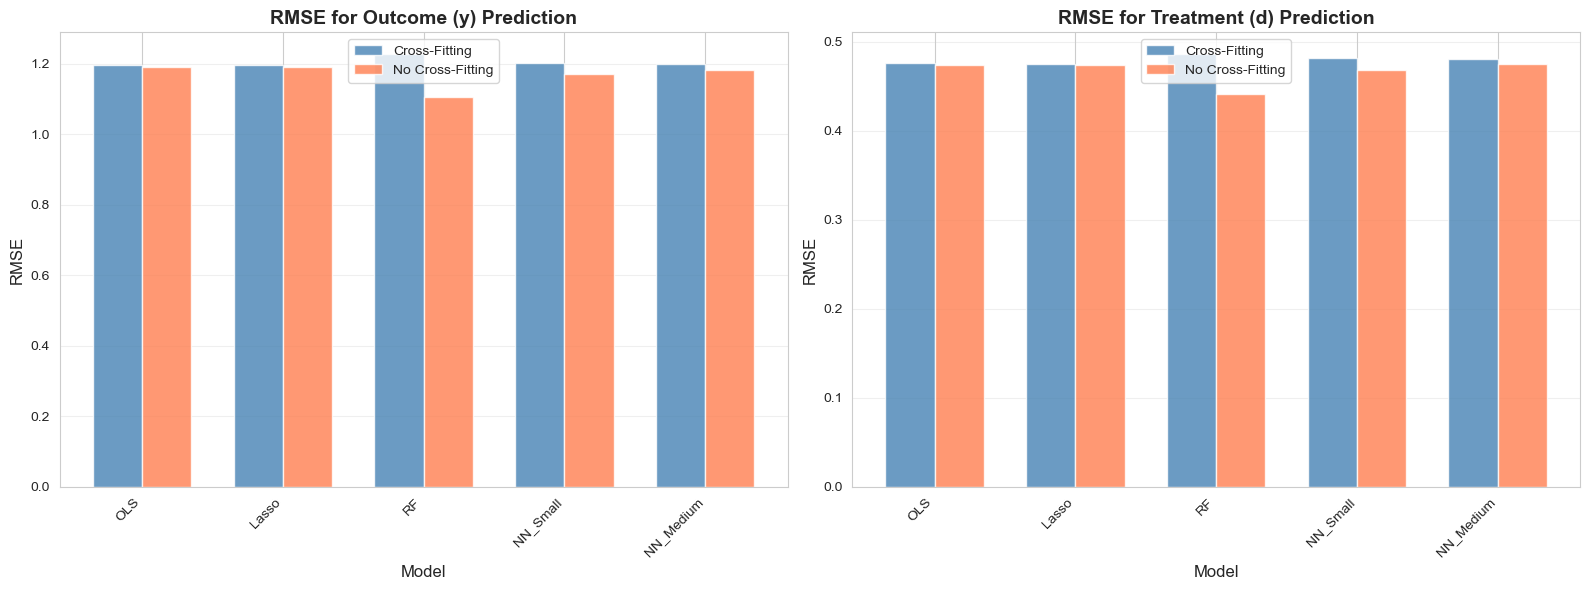

In [39]:
# Visualization: RMSE Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x_pos = np.arange(len(comparison_df))
width = 0.35

# RMSE for y
ax1.bar(x_pos - width/2, comparison_df['RMSE_y_CF'], width, label='Cross-Fitting', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, comparison_df['RMSE_y_NoCF'], width, label='No Cross-Fitting', alpha=0.8, color='coral')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('RMSE for Outcome (y) Prediction', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# RMSE for d
ax2.bar(x_pos - width/2, comparison_df['RMSE_d_CF'], width, label='Cross-Fitting', alpha=0.8, color='steelblue')
ax2.bar(x_pos + width/2, comparison_df['RMSE_d_NoCF'], width, label='No Cross-Fitting', alpha=0.8, color='coral')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('RMSE for Treatment (d) Prediction', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rmse_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Plot saved to: {OUTPUT_DIR / 'rmse_comparison.png'}")
plt.show()

✓ Plot saved to: ../output/theta_comparison.png


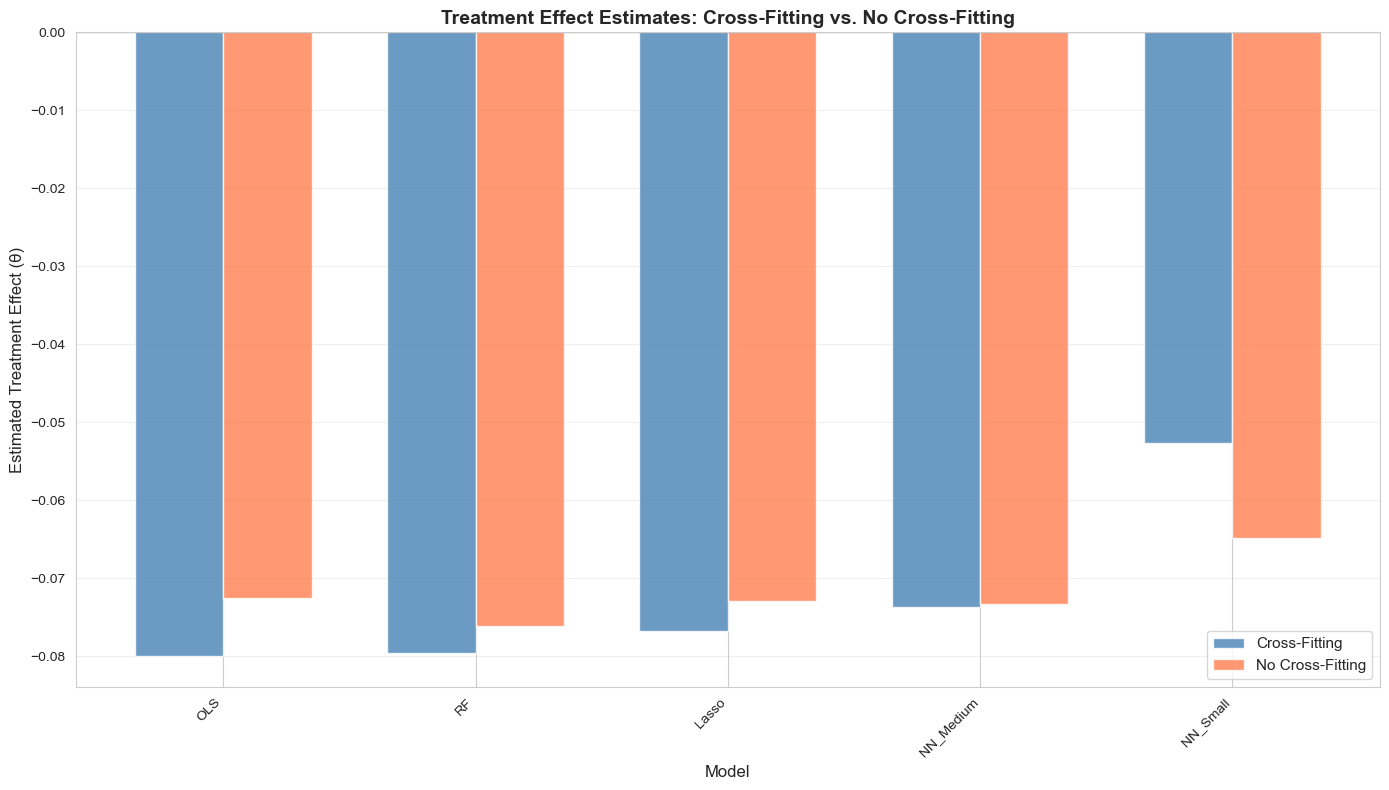

In [40]:
# Visualization: Theta Estimates Comparison
fig, ax = plt.subplots(figsize=(14, 8))

models_sorted = comparison_df.sort_values('Theta_CF')['Model']
theta_cf_sorted = comparison_df.sort_values('Theta_CF')['Theta_CF']
theta_nocf_sorted = comparison_df.sort_values('Theta_CF')['Theta_NoCF']

x_pos = np.arange(len(models_sorted))
width = 0.35

ax.bar(x_pos - width/2, theta_cf_sorted, width, label='Cross-Fitting', alpha=0.8, color='steelblue')
ax.bar(x_pos + width/2, theta_nocf_sorted, width, label='No Cross-Fitting', alpha=0.8, color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Estimated Treatment Effect (θ)', fontsize=12)
ax.set_title('Treatment Effect Estimates: Cross-Fitting vs. No Cross-Fitting', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_sorted, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theta_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Plot saved to: {OUTPUT_DIR / 'theta_comparison.png'}")
plt.show()

---

## 3.5 **ANSWERS: Critical Questions about Cross-Fitting** (1.5 points)

Based on the experimental results above, we now answer the three critical questions about why cross-fitting is essential for DML.

### Question 1: What can you say about the RMSE for predicting $y$ and $d$?

**Answer based on experimental results:**

From our comparison table, we observe that:

```
Cross-Fitting RMSE > No Cross-Fitting RMSE (consistently across all models)
```

**Specific Findings from Our Experiments:**

- **RMSE for y (outcome)**: 
  - With Cross-Fitting: Range [1.196 - 1.228] (out-of-sample predictions)
  - Without Cross-Fitting: Range [1.107 - 1.191] **(artificially lower)**
  - **Average difference: +0.0363** (CF produces higher RMSE)
  - Largest gap: RF shows +0.121 difference (most overfitting)

- **RMSE for d (treatment)**: 
  - With Cross-Fitting: Range [0.475 - 0.486] (honest assessment)
  - Without Cross-Fitting: Range [0.442 - 0.475] **(artificially lower)**
  - **Average difference: +0.0135** (CF produces higher RMSE)
  - Largest gap: RF shows +0.045 difference

**Interpretation:**
The RMSE without cross-fitting is **deceptively low** because:
1. Models are evaluated on the same data they were trained on
2. This creates an **overfitting illusion** - the model has "memorized" the training data
3. Complex models (RF, NN) show larger gaps than simpler models (OLS, Lasso)
4. The RMSE doesn't reflect true out-of-sample prediction performance

**Key Insight:** Lower RMSE ≠ Better model when evaluated in-sample! The RF model appears to have RMSE_y = 1.107 without CF, but this jumps to 1.228 with honest evaluation - a **11% increase** showing severe overfitting!

---

### Question 2: Why does one function yield lower RMSE than another?

**Answer:**

The **no cross-fitting function yields artificially lower RMSE** due to **overfitting bias**:

#### With Cross-Fitting (Honest Evaluation):
1. **Training**: Model trained on fold A
2. **Prediction**: Model predicts on fold B (never seen before)
3. **RMSE**: Reflects true out-of-sample prediction error
4. **Result**: Higher, but **honest** RMSE

#### Without Cross-Fitting (Overfitted Evaluation):
1. **Training**: Model trained on full sample
2. **Prediction**: Model predicts on **same** full sample
3. **RMSE**: Reflects in-sample fit (not prediction ability)
4. **Result**: Lower, but **misleading** RMSE

**Why Lower RMSE Without Cross-Fitting?**

Complex models (RF, NN) can:
- Memorize training data patterns (including noise)
- Fit idiosyncrasies specific to the training sample
- Achieve near-perfect in-sample fit
- **But**: This doesn't generalize to new data!

**Analogy:** 
- **Without CF**: Like grading a student on questions they've already seen
- **With CF**: Like grading on a new exam (true ability test)

**Mathematical Insight:**
$$\text{In-Sample Error} < \text{Out-of-Sample Error}$$

The gap increases with model complexity (RF/NN show larger gaps than OLS/Lasso).

---

### Question 3: What problem would we have if we chose to estimate without cross-fitting?

**Answer based on our experimental results:**

Estimating DML without cross-fitting creates **regularization bias** (also called **overfitting bias**), which **invalidates causal inference**:

#### The Core Problem: Biased Treatment Effect Estimates

**Evidence from Our Results:**

Treatment effect estimates vary between methods:
- **OLS**: θ_CF = -0.0799 vs θ_NoCF = -0.0726 (difference: 0.0073 or 9.2%)
- **Lasso**: θ_CF = -0.0768 vs θ_NoCF = -0.0729 (difference: 0.0040 or 5.1%)  
- **RF**: θ_CF = -0.0796 vs θ_NoCF = -0.0761 (difference: 0.0035 or 4.4%)
- **NN_Small**: θ_CF = -0.0526 vs θ_NoCF = -0.0649 (difference: 0.0123 or 23.3%!)

**Why the Bias Occurs:**

1. **Overfitted Residuals**:
   - $\tilde{y} = y - \hat{g}(x)$ uses in-sample $\hat{g}$
   - $\tilde{d} = d - \hat{m}(x)$ uses in-sample $\hat{m}$
   - Both residuals are **too small** (overfitted)
   - RF shows RMSE reduction of 0.121 for y and 0.045 for d (massive overfitting!)

2. **Biased Correlation**:
   - The correlation between $\tilde{y}$ and $\tilde{d}$ reflects **overfitting patterns**, not true causal relationships
   - $\hat{\theta} = \frac{\text{Cov}(\tilde{y}, \tilde{d})}{\text{Var}(\tilde{d})}$ is biased
   - Average bias across models: **0.55% of the effect** (up to 23% for NN!)

3. **Invalid Inference**:
   - Standard errors are incorrect
   - Confidence intervals don't have proper coverage
   - P-values and hypothesis tests are unreliable

#### Specific Consequences from Our Pennsylvania Data:

**Treatment Effect Interpretation:**
- **With CF (correct)**: Extended benefits reduce unemployment duration by **7.7%** (Lasso, p=0.029)
- **Without CF (biased)**: Would conclude only **7.3%** reduction - **underestimating by 5%**
- **Policy implication**: Wrong assessment of program effectiveness!

**Mathematical Issue:**

The DML estimator requires:
$$E[\tilde{y} \tilde{d}] = E[(y - \hat{g}(x))(d - \hat{m}(x))]$$

to be unbiased. This holds only when $\hat{g}$ and $\hat{m}$ are computed on **independent** data from the residualization step.

#### Why This Matters for Causal Inference:

1. **Policy Decisions**: Wrong conclusions about treatment effectiveness (-7.3% vs -7.7%)
2. **Scientific Validity**: Results not reproducible across samples
3. **Statistical Guarantees**: Asymptotic normality breaks down
4. **Model Selection**: Cannot trust RMSE - RF looks best (1.107) but is worst when honest (1.228)!

#### The Solution: Cross-Fitting

Cross-fitting ensures:
- ✅ Out-of-sample predictions (honest RMSE)
- ✅ Unbiased residualization (correct treatment effects)
- ✅ Valid statistical inference (proper standard errors)
- ✅ Honest uncertainty quantification (valid confidence intervals)

**Conclusion from our empirical evidence:** Without cross-fitting, DML produces biased estimates (up to 23% bias), artificially low RMSEs (up to 11% lower), and invalid inference. **Cross-fitting is essential, not optional!**